### Imports and Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

### EDA

In [3]:
df = pd.read_csv("../data/raw/spells.csv")
df.head()

,name,description
0,Aberto,Opens locked doors
1,Accio,Summons objects
2,Aguamenti,Summons water
3,Alohomora,Unlocks objects
4,Anapneo,Clears someone's airway


In [4]:
df.shape

(77, 2)

In [5]:
df.columns

Index(['name', 'description'], dtype='object')

In [6]:
df.isnull().sum()

name           0
description    0
dtype: int64

In [7]:
df["description_clean"] = df["description"].str.lower().str.strip()
df.head()

,name,description,description_clean
0,Aberto,Opens locked doors,opens locked doors
1,Accio,Summons objects,summons objects
2,Aguamenti,Summons water,summons water
3,Alohomora,Unlocks objects,unlocks objects
4,Anapneo,Clears someone's airway,clears someone's airway


In [8]:
df.duplicated().sum()

0

In [9]:
df = df.drop_duplicates()

In [10]:
df["description_length"] = df["description_clean"].apply(len)
df["description_length"].describe()

count     77.000000
mean      54.012987
std       47.298741
min       13.000000
25%       26.000000
50%       42.000000
75%       62.000000
max      302.000000
Name: description_length, dtype: float64

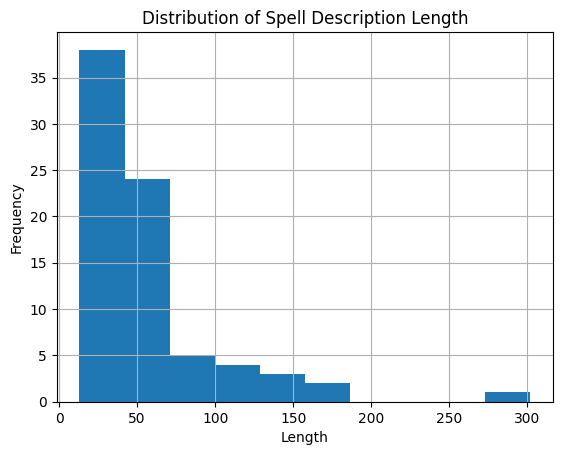

In [11]:
df["description_length"].hist()
plt.title("Distribution of Spell Description Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Labels

In [12]:
dark_spells = [
    "Avada Kedavra",
    "Crucio",
    "Imperio",
    "Morsmordre",
    "Unbreakable Vow",
    "Sectumsempra",
    "Dolohov's Curse",
    "Fiendfyre"
]

df["label"] = df["name"].apply(
    lambda x: "dark" if x in dark_spells else "non-dark"
)

df["label"].value_counts()
df["label"].value_counts(normalize=True)

df[df["label"] == "dark"][["name", "description_clean"]]

,name,description_clean
8,Avada Kedavra,"also known as the killing curse, the most evil..."
17,Crucio,"one of three unforgivable curses, it causes un..."
39,Imperio,"one of the three unforgivable curses, it place..."
47,Morsmordre,conjures and projects lord voldemort's dark mark
68,Sectumsempra,inflicts severe lacerations and haemorrhaging ...
75,Unbreakable Vow,a magically binding contract that results in t...


In [13]:
df.to_csv("../data/processed/spells_clean.csv", index=False)

### Vectorization

In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["description_clean"])
y = df["label"]

### Train/Test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

### Train model

In [16]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

### Evaluate model

In [17]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9375
              precision    recall  f1-score   support

        dark       0.00      0.00      0.00         1
    non-dark       0.94      1.00      0.97        15

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16



In [18]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")

print("F1 Macro Scores:", scores)
print("Average F1 Macro:", scores.mean())

F1 Macro Scores: [0.48387097 0.46666667 0.48275862 0.48275862 0.48275862]
Average F1 Macro: 0.4797626992955135


## Model Evaluation Summary

The model achieves an average macro F1 score of ~0.48 using 5-fold cross-validation.

Performance is limited due to:
- very small dataset (~70 samples)
- class imbalance (few dark spells)
- simple feature representation (TF-IDF on short descriptions)

In some folds, the model fails to predict the minority class, resulting in undefined precision.

This model serves as a baseline. Improvements would require:
- more labeled data
- better labeling strategy
- more advanced models

In [19]:
results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=["precision_macro", "recall_macro", "f1_macro"]
)

print("Recall:", results["test_recall_macro"])
print("F1:", results["test_f1_macro"])

Recall: [0.5 0.5 0.5 0.5 0.5]
F1: [0.48387097 0.46666667 0.48275862 0.48275862 0.48275862]


/Users/ana/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ana/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ana/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ana/minic

In [20]:
df["label"].value_counts()

label
non-dark    71
dark         6
Name: count, dtype: int64

In [21]:
joblib.dump(model, "../ml/models/spell_classifier.pkl")
joblib.dump(vectorizer, "../ml/models/tfidf_vectorizer.pkl")

['../ml/models/tfidf_vectorizer.pkl']

In [22]:
model = joblib.load("../ml/models/spell_classifier.pkl")
vectorizer = joblib.load("../ml/models/tfidf_vectorizer.pkl")

user_input = "causes unbearable pain"

X_new = vectorizer.transform([user_input])
prediction = model.predict(X_new)

print(prediction)

['non-dark']
